In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
get_ipython().run_line_magic('matplotlib', 'inline')

from sklearn.metrics import accuracy_score,fbeta_score,classification_report
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
#nltk.download('stopwords')
stop=stopwords.words("english")

from nltk.stem.porter import PorterStemmer
from nltk.stem import SnowballStemmer
ss = SnowballStemmer("english")
ps = PorterStemmer()


In [2]:
df_news = pd.read_csv('News_Train.csv')


In [3]:
df_news.shape


(1490, 3)

In [4]:
stop

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [5]:
df_news= pd.read_csv('News_Train.csv')
df_news.shape
df_news.head(5)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [6]:
df_news.describe()

,ArticleId
count,1490.000000
mean,1119.696644
std,641.826283
min,2.000000
25%,565.250000
50%,1112.500000
75%,1680.750000
max,2224.000000


In [7]:
df_news.groupby('Category').describe().T

Category            business  entertainment     politics        sport  \
ArticleId count   336.000000     273.000000   274.000000   346.000000   
          mean   1104.315476    1100.274725  1134.317518  1104.057803   
          std     658.063510     615.695597   637.628980   649.542516   
          min       2.000000      10.000000     7.000000     4.000000   
          25%     476.250000     601.000000   610.000000   513.500000   
          50%    1107.500000    1081.000000  1163.000000  1070.000000   
          75%    1716.250000    1611.000000  1681.500000  1689.500000   
          max    2221.000000    2223.000000  2224.000000  2219.000000   

Category                tech  
ArticleId count   261.000000  
          mean   1165.195402  
          std     643.852459  
          min      20.000000  
          25%     631.000000  
          50%    1147.000000  
          75%    1755.000000  
          max    2216.000000

In [8]:
df_news["Category"].value_counts()

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

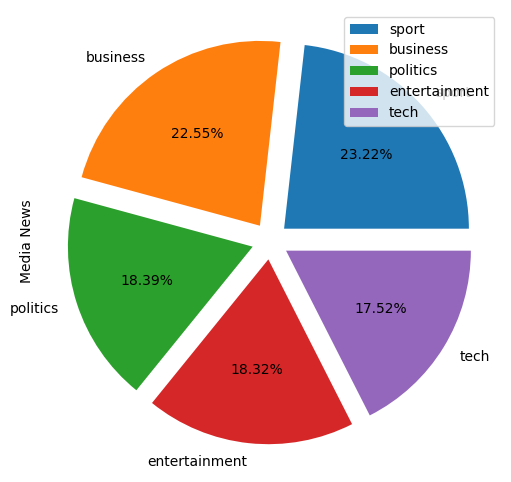

In [9]:
df_news["Category"].value_counts().plot(kind = 'pie', explode = [0.1, 0.1,0.1,0.1,0.1], figsize = (6, 6), autopct = '%1.2f%%')
plt.ylabel("Media News")
plt.legend(["sport", "business","politics","entertainment","tech"])
plt.show()

In [10]:
df_news.groupby("Category")["Text"].agg([len, np.max]).sort_values(by = "len", ascending = False).head(n = 10)

C:\Users\UniTECH\AppData\Local\Temp\ipykernel_11476\263091102.py:1: FutureWarning: The provided callable <function max at 0x000001D5B9E04C20> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_news.groupby("Category")["Text"].agg([len, np.max]).sort_values(by = "len", ascending = False).head(n = 10)


,len,max
Category,,
sport,346,young debut cut short by ginepri fifteen-year-...
business,336,yukos unit fetches $9bn at auction a little-kn...
politics,274,woolf murder sentence rethink plans to give mu...
entertainment,273,youssou n dour wins music prize senegalese mus...
tech,261,yahoo moves into desktop search internet giant...


In [11]:
df_news['length']= df_news['Text'].apply(len)
df_news.head()

,ArticleId,Text,Category,length
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866
1,154,german business confidence slides german busin...,business,2016
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104
3,1976,lifestyle governs mobile choice faster bett...,tech,3618
4,917,enron bosses in $168m payout eighteen former e...,business,2190


In [12]:
df_news.length.describe()

count     1490.000000
mean      2233.461745
std       1205.153358
min        501.000000
25%       1453.000000
50%       1961.000000
75%       2751.250000
max      18387.000000
Name: length, dtype: float64

In [13]:
df_news[df_news['length']==910]['Text'].iloc[0]

'oil prices fall back from highs oil prices retreated from four-month highs in early trading on tuesday after producers  cartel opec said it was now unlikely to cut production.  following the comments by acting opec secretary general adnan shihab-eldin  us light crude fell 32 cents to $51.43 a barrel. he said that high oil prices meant opec was unlikely to stick to its plan to cut output in the second quarter. in london  brent crude fell 32 cents to $49.74 a barrel.  opec members are next meeting to discuss production levels on 16 march. on monday  oil prices rose for a sixth straight session  reaching a four-month high as cold weather in the us threatened stocks of heating oil. us demand for heating oil was predicted to be about 14% above normal this week  while stocks were currently about 7.5% below the levels of a year ago. cold weather across europe has also put upward pressure on crude prices.'

array([[<Axes: title={'center': 'business'}>,
        <Axes: title={'center': 'entertainment'}>],
       [<Axes: title={'center': 'politics'}>,
        <Axes: title={'center': 'sport'}>],
       [<Axes: title={'center': 'tech'}>, <Axes: >]], dtype=object)

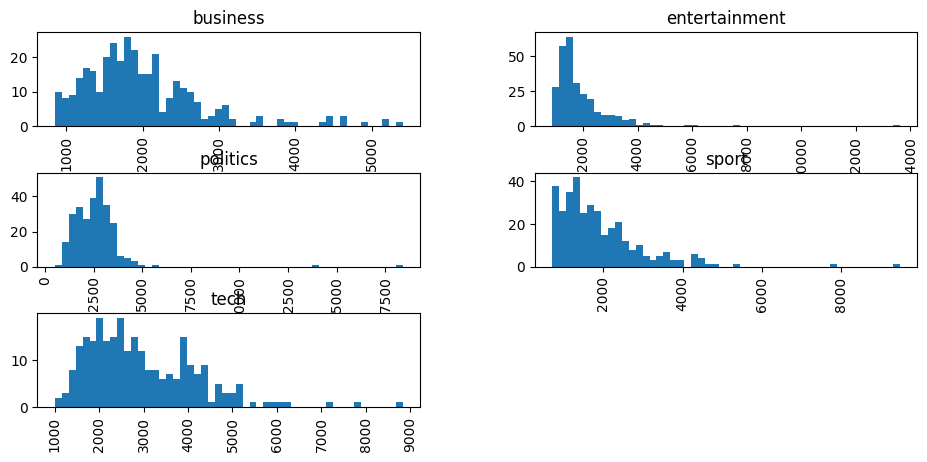

In [14]:
df_news.hist(column='length', by='Category', bins=50,figsize=(11,5))

In [15]:
df_news.head(4)

,ArticleId,Text,Category,length
0,1833,worldcom ex-boss launches defence lawyers defe...,business,1866
1,154,german business confidence slides german busin...,business,2016
2,1101,bbc poll indicates economic gloom citizens in ...,business,3104
3,1976,lifestyle governs mobile choice faster bett...,tech,3618


In [16]:
import string
def cleanText(message):
    #message = message.translate(str.maketrans('ranjan', 'ranjan', string.punctuation))
    message = re.sub('[^a-zA-Z]', ' ', message)
    message = message.lower()
    message = message.split()
    words = [ss.stem(word) for word in message if word not in stop]
    return " ".join(words)

df_news["Text"] = df_news["Text"].apply(cleanText)
df_news.head(n = 10)

,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,business,1866
1,154,german busi confid slide german busi confid fe...,business,2016
2,1101,bbc poll indic econom gloom citizen major nati...,business,3104
3,1976,lifestyl govern mobil choic faster better funk...,tech,3618
4,917,enron boss payout eighteen former enron direct...,business,2190
5,1582,howard truant play snooker conserv leader mich...,politics,1588
6,651,wale silent grand slam talk rhys william say w...,sport,1988
7,1797,french honour director parker british film dir...,entertainment,1342
8,2034,car giant hit merced slump slump profit luxuri...,business,2609
9,1866,focker fuel festiv film chart comedi meet fock...,entertainment,1368


In [17]:
sport_messages = df_news[df_news["Category"] == "sport"]["Text"]

business_messages = df_news[df_news["Category"] == "business"]["Text"]

politics_messages = df_news[df_news["Category"] == "politics"]["Text"]

entertainment_messages = df_news[df_news["Category"] == "entertainment"]["Text"]

tech_messages = df_news[df_news["Category"] == "tech"]["Text"]

In [18]:
sport_messages

6       wale silent grand slam talk rhys william say w...
14      ireland argentina injuri time drop goal ronan ...
15      wenger sign new deal arsenal manag arsene weng...
17      hantuchova dubai last eight daniela hantuchova...
18      melzer shock agassi san jose second seed andr ...
                              ...                        
1467    charvi set lose fit bid flanker colin charvi u...
1468    preview ireland v england sun lansdown road du...
1471    ferrero eye return top form former world numbe...
1473    dallaglio eye lion tour place former england c...
1481    liverpool pledg keep gerrard liverpool chief e...
Name: Text, Length: 346, dtype: object

In [19]:
business_messages

0       worldcom ex boss launch defenc lawyer defend f...
1       german busi confid slide german busi confid fe...
2       bbc poll indic econom gloom citizen major nati...
4       enron boss payout eighteen former enron direct...
8       car giant hit merced slump slump profit luxuri...
                              ...                        
1474    indi buy india paper irish publish group indep...
1479    high fuel cost hit us airlin two largest airli...
1480    qanta see profit fli record australian airlin ...
1484    hyundai build new india plant south korea hyun...
1487    weak dollar hit reuter revenu media group reut...
Name: Text, Length: 336, dtype: object

In [20]:
politics_messages

5       howard truant play snooker conserv leader mich...
10      blair reject iraq advic call toni blair reject...
28      uk stand firm eu rebat britain bn eu rebat ren...
33      secur paper found street inquiri way file cont...
52      mps quiz aid royal incom senior offici two bod...
                              ...                        
1456    blair told doubl oversea aid toni blair urg us...
1463    abba toler attack palestinian leader mahmoud a...
1472    kelli trail new disciplin power teacher could ...
1475    budget set scene elect gordon brown seek put e...
1478    visa row mandarin made sir john top civil serv...
Name: Text, Length: 274, dtype: object

In [21]:
entertainment_messages

7       french honour director parker british film dir...
9       focker fuel festiv film chart comedi meet fock...
11      housew lift channel rate debut us televis hit ...
16      u desir number one u three prestigi grammi awa...
21      carri star patsi rowland die actress patsi row...
                              ...                        
1462    da vinci code lousi histori plot intern bestse...
1476    bollywood draw global star british actress ant...
1483    beasti boy win sampl battl us rapper beasti bo...
1485    doubl evict big brother model capric holbi cit...
1486    dj doubl act revamp chart show dj duo jk joel ...
Name: Text, Length: 273, dtype: object

In [22]:
tech_messages 

3       lifestyl govern mobil choic faster better funk...
19      move mobil improv golf swing mobil phone recog...
24      bt boost broadband packag british telecom said...
26      peer peer net stay peer peer p p network stay ...
30      pompeii get digit make old fashion audio tour ...
                              ...                        
1469    warn woeful wi fi secur compani get wors keep ...
1477    web log aid disast recoveri vivid descript dev...
1482    file swapper readi new network legal attack we...
1488    appl ipod famili expand market appl expand ipo...
1489    santi worm make unwelcom visit thousand websit...
Name: Text, Length: 261, dtype: object

In [23]:
#nltk.download('punkt')

In [24]:
sport_words = []
business_words = []
entertainment_words = []
politics_words = []
tech_words = []


def extractSportWords(sportNews):
    global sport_words
    words = [word for word in word_tokenize(sportNews)]
    sport_words= sport_words + words
    
def extractBusinessWords(businessNews):
    global business_words
    words = [word for word in word_tokenize(businessNews) ]
    business_words = business_words + words

    
def extractPoliticsWords(politicsNews):
    global politics_words
    words = [word for word in word_tokenize(politicsNews) ]
    politics_words = politics_words + words
    
    
    
def extractEntertainmentWords(entertainmentNews):
    global entertainment_words
    words = [word for word in word_tokenize(entertainmentNews) ]
    entertainment_words = entertainment_words + words
    
    

def extractTechWords(techNews):
    global tech_words
    words = [word for word in word_tokenize(techNews) ]
    tech_words = tech_words + words
    
    
    
    
sport_messages.apply(extractSportWords)

business_messages.apply(extractBusinessWords)

politics_messages.apply(extractPoliticsWords)

entertainment_messages.apply(extractEntertainmentWords)

tech_messages.apply(extractTechWords)





3       None
19      None
24      None
26      None
30      None
        ... 
1469    None
1477    None
1482    None
1488    None
1489    None
Name: Text, Length: 261, dtype: object

In [25]:
sport_words

['wale',
 'silent',
 'grand',
 'slam',
 'talk',
 'rhys',
 'william',
 'say',
 'wale',
 'still',
 'think',
 'win',
 'grand',
 'slam',
 'despit',
 'third',
 'six',
 'nation',
 'win',
 'last',
 'thing',
 'mind',
 'moment',
 'said',
 'william',
 'second',
 'half',
 'replac',
 'saturday',
 'win',
 'franc',
 'pari',
 'realis',
 'difficult',
 'task',
 'go',
 'scotland',
 'beat',
 'come',
 'unstuck',
 'coupl',
 'time',
 'recent',
 'focus',
 'game',
 'worri',
 'ireland',
 'hope',
 'beaten',
 'scotland',
 'captain',
 'gareth',
 'thoma',
 'rule',
 'rest',
 'campaign',
 'broken',
 'thumb',
 'william',
 'vy',
 'first',
 'start',
 'championship',
 'far',
 'kevin',
 'morgan',
 'probabl',
 'favourit',
 'replac',
 'thoma',
 'full',
 'back',
 'leav',
 'william',
 'hal',
 'luscomb',
 'battl',
 'right',
 'wing',
 'berth',
 'hamstr',
 'injuri',
 'deni',
 'luscomb',
 'opportun',
 'make',
 'third',
 'success',
 'start',
 'dragon',
 'winger',
 'expect',
 'fit',
 'trip',
 'murrayfield',
 'march',
 'hooker',
 '

In [26]:
business_words

['worldcom',
 'ex',
 'boss',
 'launch',
 'defenc',
 'lawyer',
 'defend',
 'former',
 'worldcom',
 'chief',
 'berni',
 'ebber',
 'batteri',
 'fraud',
 'charg',
 'call',
 'compani',
 'whistleblow',
 'first',
 'wit',
 'cynthia',
 'cooper',
 'worldcom',
 'ex',
 'head',
 'intern',
 'account',
 'alert',
 'director',
 'irregular',
 'account',
 'practic',
 'us',
 'telecom',
 'giant',
 'warn',
 'led',
 'collaps',
 'firm',
 'follow',
 'discoveri',
 'bn',
 'bn',
 'account',
 'fraud',
 'mr',
 'ebber',
 'plead',
 'guilti',
 'charg',
 'fraud',
 'conspiraci',
 'prosecut',
 'lawyer',
 'argu',
 'mr',
 'ebber',
 'orchestr',
 'seri',
 'account',
 'trick',
 'worldcom',
 'order',
 'employe',
 'hide',
 'expens',
 'inflat',
 'revenu',
 'meet',
 'wall',
 'street',
 'earn',
 'estim',
 'ms',
 'cooper',
 'run',
 'consult',
 'busi',
 'told',
 'juri',
 'new',
 'york',
 'wednesday',
 'extern',
 'auditor',
 'arthur',
 'andersen',
 'approv',
 'worldcom',
 'account',
 'earli',
 'said',
 'andersen',
 'given',
 'green',

In [27]:
entertainment_words

['french',
 'honour',
 'director',
 'parker',
 'british',
 'film',
 'director',
 'sir',
 'alan',
 'parker',
 'made',
 'offic',
 'order',
 'art',
 'letter',
 'one',
 'franc',
 'highest',
 'cultur',
 'honour',
 'sir',
 'alan',
 'receiv',
 'decor',
 'pari',
 'wednesday',
 'french',
 'cultur',
 'minist',
 'renaud',
 'donnedieu',
 'de',
 'vabr',
 'explor',
 'possibl',
 'film',
 'immens',
 'talent',
 'mr',
 'de',
 'vabr',
 'said',
 'present',
 'award',
 'parker',
 'prais',
 'french',
 'film',
 'say',
 'hollywood',
 'creat',
 'modern',
 'cinema',
 'use',
 'commod',
 'told',
 'minist',
 'honour',
 'thus',
 'distinguish',
 'franc',
 'flag',
 'carrier',
 'cinema',
 'throughout',
 'world',
 'sir',
 'alan',
 'film',
 'includ',
 'oscar',
 'win',
 'fame',
 'plus',
 'midnight',
 'express',
 'commit',
 'found',
 'member',
 'director',
 'guild',
 'great',
 'britain',
 'former',
 'chairman',
 'uk',
 'film',
 'council',
 'board',
 'british',
 'film',
 'institut',
 'work',
 'campaign',
 'shown',
 'us',
 '

In [28]:
politics_words

['howard',
 'truant',
 'play',
 'snooker',
 'conserv',
 'leader',
 'michael',
 'howard',
 'admit',
 'use',
 'play',
 'truant',
 'spend',
 'time',
 'school',
 'friend',
 'snooker',
 'hall',
 'mr',
 'howard',
 'said',
 'time',
 'jack',
 'snooker',
 'hall',
 'llanelli',
 'done',
 'last',
 'damag',
 'told',
 'time',
 'educ',
 'supplement',
 'truanci',
 'bad',
 'said',
 'firm',
 'action',
 'need',
 'mr',
 'howard',
 'also',
 'call',
 'return',
 'level',
 'classroom',
 'disciplin',
 'mr',
 'howard',
 'eventu',
 'left',
 'llanelli',
 'grammar',
 'school',
 'snooker',
 'hall',
 'go',
 'cambridg',
 'univers',
 'said',
 'think',
 'done',
 'last',
 'damag',
 'made',
 'snooker',
 'world',
 'champion',
 'might',
 'occas',
 'left',
 'earli',
 'afternoon',
 'honest',
 'think',
 'truanci',
 'bad',
 'thing',
 'firm',
 'action',
 'taken',
 'deal',
 'anoth',
 'player',
 'fail',
 'win',
 'snooker',
 'world',
 'championship',
 'jimmi',
 'whirlwind',
 'white',
 'previous',
 'admit',
 'miss',
 'lesson',
 'in

In [29]:
tech_words

['lifestyl',
 'govern',
 'mobil',
 'choic',
 'faster',
 'better',
 'funkier',
 'hardwar',
 'alon',
 'go',
 'help',
 'phone',
 'firm',
 'sell',
 'handset',
 'research',
 'suggest',
 'instead',
 'phone',
 'firm',
 'keen',
 'get',
 'custom',
 'push',
 'technolog',
 'sake',
 'consum',
 'far',
 'interest',
 'handset',
 'fit',
 'lifestyl',
 'screen',
 'size',
 'onboard',
 'memori',
 'chip',
 'insid',
 'show',
 'depth',
 'studi',
 'handset',
 'maker',
 'ericsson',
 'histor',
 'industri',
 'much',
 'focus',
 'use',
 'technolog',
 'said',
 'dr',
 'michael',
 'bjorn',
 'senior',
 'advisor',
 'mobil',
 'media',
 'ericsson',
 'consum',
 'enterpris',
 'lab',
 'stop',
 'say',
 'technolog',
 'chang',
 'live',
 'said',
 'tri',
 'speak',
 'consum',
 'languag',
 'help',
 'see',
 'fit',
 'told',
 'bbc',
 'news',
 'websit',
 'studi',
 'ericsson',
 'interview',
 'mobil',
 'phone',
 'owner',
 'way',
 'use',
 'phone',
 'peopl',
 'habit',
 'remain',
 'said',
 'dr',
 'bjorn',
 'move',
 'activ',
 'mobil',
 'pho

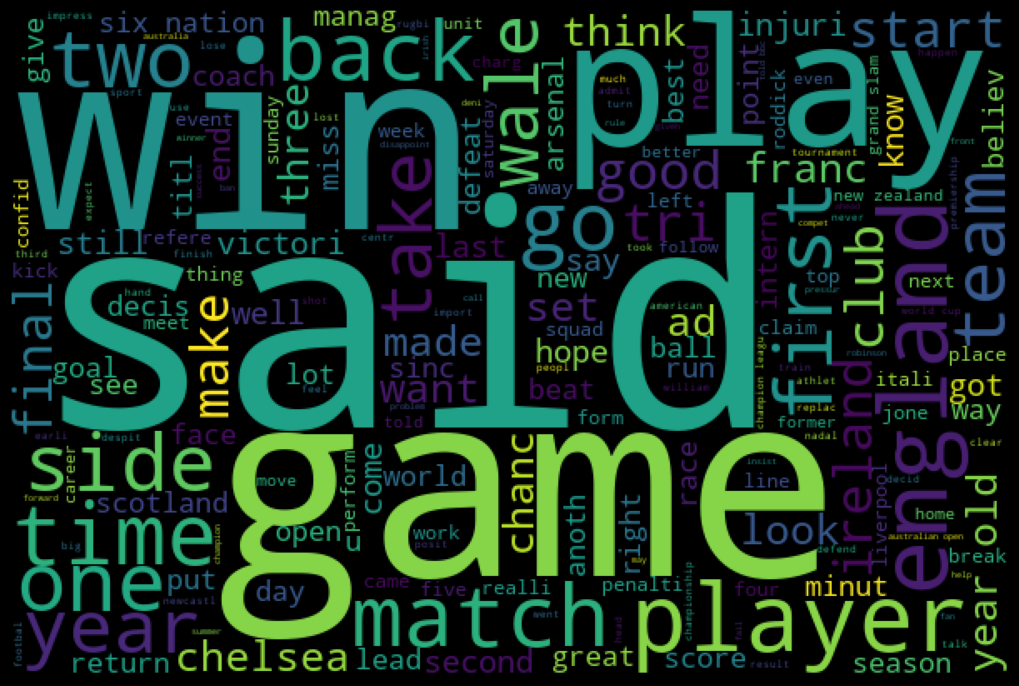

In [30]:
sport_wordcloud = WordCloud(width=600, height=400).generate(" ".join(sport_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(sport_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

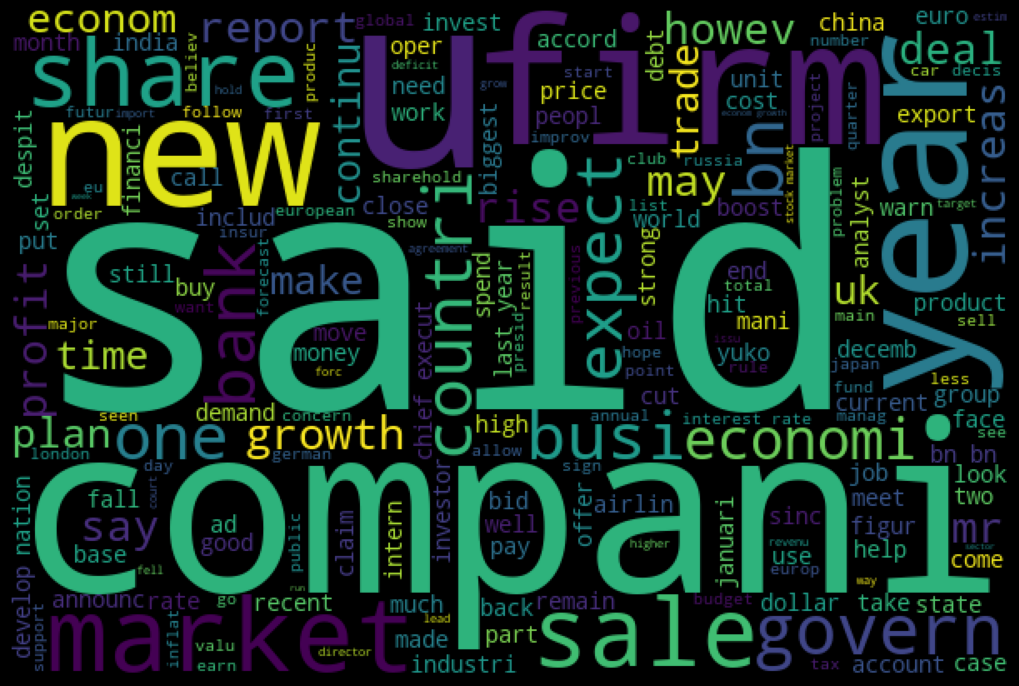

In [31]:
business_wordcloud = WordCloud(width=600, height=400).generate(" ".join(business_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(business_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


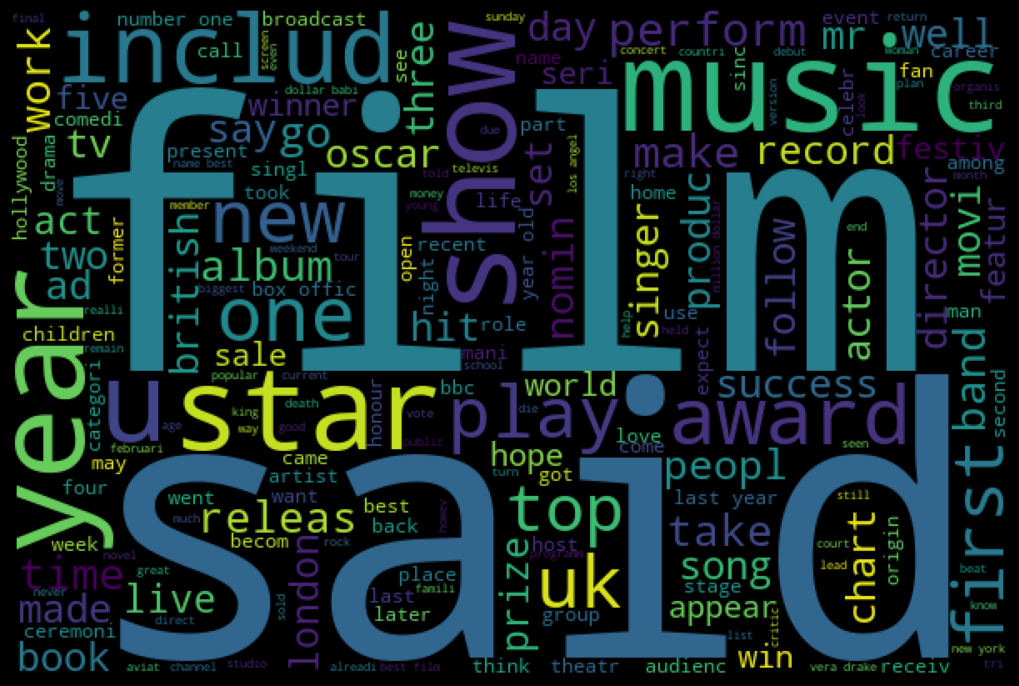

In [32]:
entertainment_wordcloud = WordCloud(width=600, height=400).generate(" ".join(entertainment_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(entertainment_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

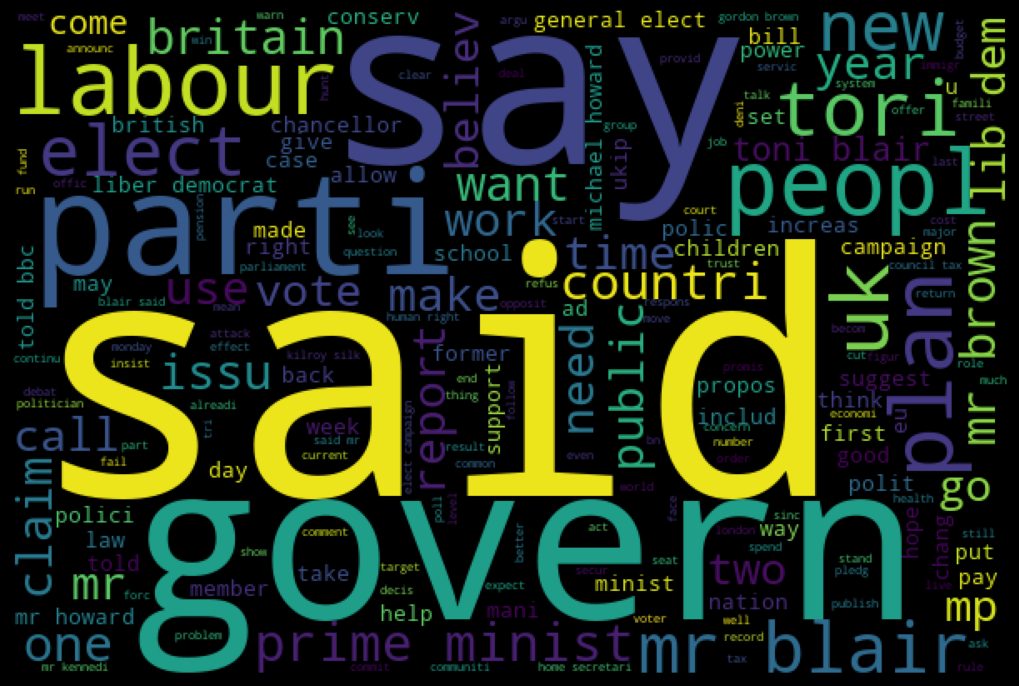

In [33]:
politics_wordcloud = WordCloud(width=600, height=400).generate(" ".join(politics_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(politics_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

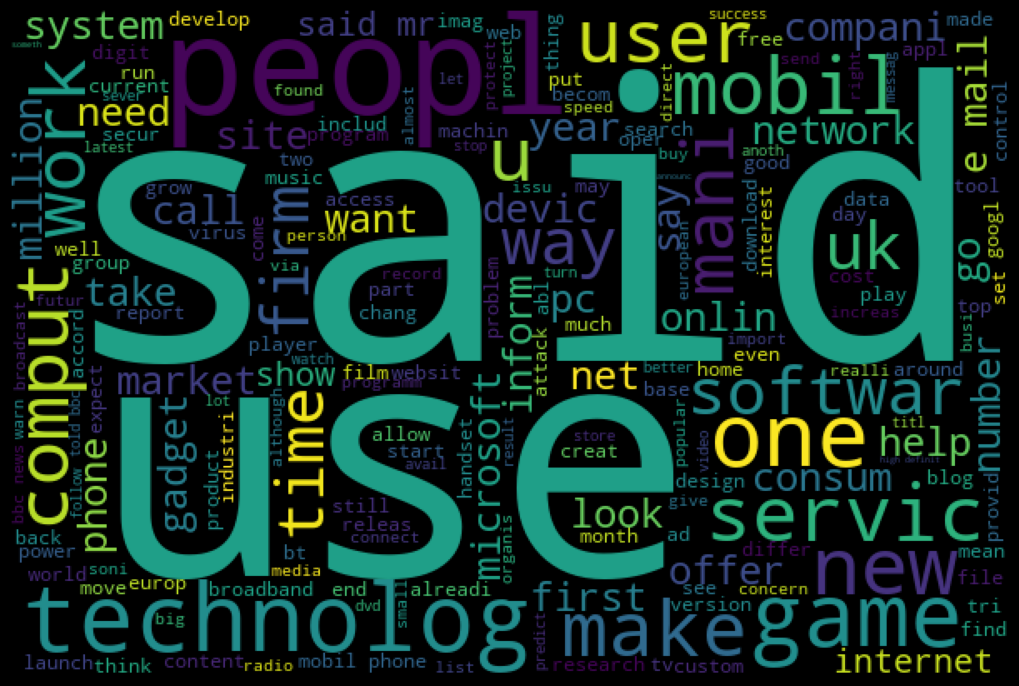

In [34]:
tech_wordcloud = WordCloud(width=600, height=400).generate(" ".join(tech_words))
plt.figure( figsize=(10,8), facecolor='k')
plt.imshow(tech_wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [35]:
df_news

,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,business,1866
1,154,german busi confid slide german busi confid fe...,business,2016
2,1101,bbc poll indic econom gloom citizen major nati...,business,3104
3,1976,lifestyl govern mobil choic faster better funk...,tech,3618
4,917,enron boss payout eighteen former enron direct...,business,2190
...,...,...,...,...
1485,857,doubl evict big brother model capric holbi cit...,entertainment,1266
1486,325,dj doubl act revamp chart show dj duo jk joel ...,entertainment,3111
1487,1590,weak dollar hit reuter revenu media group reut...,business,1370
1488,1587,appl ipod famili expand market appl expand ipo...,tech,3242


In [36]:
def encodeCategory(cat):
    if cat == "sport":
        return 1
    elif cat == "business":
        return 2
    elif cat == "politics":
        return 3
    elif cat == "entertainment":
        return 4
    elif cat == "tech":
        return 5
    else:
        return 0
        
df_news["Category"] =df_news["Category"].apply(encodeCategory)

In [37]:
df_news

,ArticleId,Text,Category,length
0,1833,worldcom ex boss launch defenc lawyer defend f...,2,1866
1,154,german busi confid slide german busi confid fe...,2,2016
2,1101,bbc poll indic econom gloom citizen major nati...,2,3104
3,1976,lifestyl govern mobil choic faster better funk...,5,3618
4,917,enron boss payout eighteen former enron direct...,2,2190
...,...,...,...,...
1485,857,doubl evict big brother model capric holbi cit...,4,1266
1486,325,dj doubl act revamp chart show dj duo jk joel ...,4,3111
1487,1590,weak dollar hit reuter revenu media group reut...,2,1370
1488,1587,appl ipod famili expand market appl expand ipo...,5,3242


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(encoding = "latin-1", strip_accents = "unicode")
features = vec.fit_transform(df_news["Text"])
print(features.shape)

(1490, 15883)


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X=cv.fit_transform(df_news["Text"])
print (X.shape)

(1490, 15883)


In [40]:
cv = CountVectorizer()

X=cv.fit(df_news["Text"])
X.vocabulary_

vocab = cv.get_feature_names_out()
vocab


array(['aa', 'aaa', 'aac', ..., 'zurich', 'zuton', 'zvonareva'],
      dtype=object)

In [41]:
X = cv.fit_transform(df_news["Text"]).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [42]:
print(type(cv))

<class 'sklearn.feature_extraction.text.CountVectorizer'>


In [43]:
df = pd.DataFrame(X,columns=cv.get_feature_names_out())
df
df['len']= df_news['length']
df

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1486,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1487,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1488,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
df

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1486,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1487,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1488,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [46]:
df.head()

,aa,aaa,aac,aadc,aaliyah,aaltra,aamir,aaron,abacus,abandon,...,zombi,zone,zonealarm,zoom,zooropa,zorro,zuluaga,zurich,zuton,zvonareva
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
y = df_news['Category']

In [48]:
print(df_news.columns)

Index(['ArticleId', 'Text', 'Category', 'length'], dtype='object')


In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size = 0.20, random_state = 0)

# Training model using Naive bayes classifier

from sklearn.naive_bayes import MultinomialNB
spam_detect_model = MultinomialNB().fit(X_train, y_train)

y_pred=spam_detect_model.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score,fbeta_score,classification_report

In [51]:
print(accuracy_score(y_test,y_pred))
#print(fbeta_score(y_test, y_pred, beta=0.5, average='micro'))

0.9664429530201343


In [52]:
y_pred

array([4, 3, 1, 3, 1, 2, 2, 5, 4, 2, 1, 4, 3, 5, 1, 5, 2, 4, 5, 4, 5, 5,
       4, 5, 2, 2, 3, 1, 4, 5, 4, 1, 5, 4, 4, 2, 2, 2, 5, 5, 1, 2, 3, 2,
       3, 4, 1, 4, 5, 1, 3, 1, 4, 1, 1, 4, 4, 3, 1, 4, 1, 5, 1, 2, 4, 5,
       2, 5, 2, 4, 1, 1, 4, 5, 5, 3, 3, 3, 4, 5, 5, 5, 4, 4, 5, 1, 5, 2,
       2, 2, 2, 2, 3, 5, 3, 1, 2, 5, 4, 3, 4, 2, 2, 1, 3, 2, 1, 5, 3, 2,
       4, 4, 3, 3, 4, 4, 4, 4, 5, 3, 3, 2, 3, 1, 5, 5, 1, 1, 1, 1, 1, 1,
       2, 3, 3, 1, 1, 5, 1, 3, 2, 1, 3, 2, 4, 2, 5, 4, 3, 5, 1, 1, 1, 3,
       1, 1, 2, 4, 4, 2, 4, 2, 1, 2, 1, 1, 2, 3, 1, 2, 2, 4, 1, 4, 2, 4,
       5, 3, 2, 4, 5, 5, 5, 3, 5, 1, 2, 2, 4, 1, 3, 4, 3, 5, 2, 3, 3, 1,
       4, 3, 2, 1, 5, 3, 1, 2, 1, 4, 2, 5, 4, 2, 2, 5, 2, 3, 5, 4, 1, 3,
       4, 4, 5, 3, 2, 2, 3, 5, 4, 1, 1, 3, 3, 5, 3, 5, 4, 4, 5, 3, 4, 2,
       1, 1, 1, 5, 2, 3, 4, 3, 2, 5, 5, 2, 3, 1, 3, 3, 2, 4, 2, 5, 1, 5,
       1, 2, 2, 3, 5, 3, 3, 3, 2, 5, 3, 1, 3, 5, 4, 5, 2, 5, 3, 4, 4, 1,
       1, 2, 2, 4, 5, 4, 1, 1, 5, 4, 4, 3])

In [53]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      0.95      0.98        65
           2       1.00      0.95      0.98        64
           3       0.93      1.00      0.96        53
           4       0.98      0.94      0.96        63
           5       0.91      1.00      0.95        53

    accuracy                           0.97       298
   macro avg       0.97      0.97      0.97       298
weighted avg       0.97      0.97      0.97       298



In [54]:
saved_model=pickle.dumps(spam_detect_model)

In [55]:
modelfrom_pickle = pickle.loads(saved_model) 

In [56]:
y_pred=modelfrom_pickle.predict(X_test)

In [57]:
print(accuracy_score(y_test,y_pred))

0.9664429530201343


In [58]:
import joblib

In [59]:
joblib.dump(spam_detect_model,'pickle.pkl')

['pickle.pkl']

In [60]:
spam_detect_model

MultinomialNB()

In [61]:
# Save the vectorizer object
joblib.dump(cv, 'transform.pkl')

['transform.pkl']

In [62]:
# Load the vectorizer object
vectorizer = joblib.load('transform.pkl')

In [63]:
print(type(vectorizer))

<class 'sklearn.feature_extraction.text.CountVectorizer'>
